# Référentiel communal — communes-france-2026

**Fichier** : `communes-france-2026.csv` (21 Mo) · **62 colonnes**, une ligne par commune

C'est la **pièce de liaison** du projet : c'est lui qui porte le `code_insee → (latitude, longitude)` sans lequel ni la BDIFF (localisée au code INSEE) ni CORINE ne peuvent être rattachés à la grille météo.

---

### Ce que ce notebook doit établir

| # | Question | Pourquoi |
|---|---|---|
| 1 | La clé `code_insee` est-elle propre ? | Toutes les jointures du projet en dépendent |
| 2 | Les coordonnées sont-elles exploitables ? | Elles pilotent le rattachement à la maille météo |
| 3 | Que valent les autres colonnes ? | Population, altitude, densité = features candidates |

## 1. Chargement et inventaire

⚠️ `dep_code` **doit** être lu en texte : les départements corses (`2A`, `2B`) font échouer le parsing numérique, et les départements à un chiffre perdraient leur zéro initial (`01` → `1`).

In [ ]:
# ── enregistrement automatique des figures ──
# chaque plt.show() écrit aussi un PNG dans figures/data-ville/
import sys
from pathlib import Path

for _p in (Path.cwd(), *Path.cwd().parents):
    if (_p / "src" / "tvfed").is_dir():
        sys.path.insert(0, str(_p / "src"))
        break

from tvfed.figures import activer

activer("data-ville")

In [1]:
import pandas as pd, numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

def _trouve(sc):
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / sc).exists():
            return p / sc
    raise FileNotFoundError(f"'{sc}' introuvable depuis {Path.cwd()}")

CSV = _trouve("data/ville-france/communes-france-2026.csv")

INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
BLEU, ORANGE, ROUGE, VERT = "#2a78d6", "#eb6834", "#e34948", "#1baf7a"
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
                     "font.size": 9, "axes.edgecolor": "#c3c2b7", "text.color": INK})

# ⚠️ dep_code doit être lu en TEXTE : '2A'/'2B' cassent le parsing en numérique,
#    et les codes à un chiffre perdraient leur zéro initial.
VIL = pd.read_csv(CSV, dtype={"code_insee": str, "dep_code": str, "reg_code": str,
                              "code_postal": str, "epci_code": str}, low_memory=False)
print(f"{len(VIL):,} lignes × {VIL.shape[1]} colonnes — {CSV.stat().st_size/1e6:.0f} Mo\n")
print("Colonnes par famille :")
FAM = {
    "identité":   ["code_insee", "nom_standard", "typecom", "typecom_texte"],
    "découpage":  ["reg_code", "reg_nom", "dep_code", "dep_nom", "canton_code", "epci_code"],
    "géographie": ["latitude_centre", "longitude_centre", "latitude_mairie", "longitude_mairie",
                   "altitude_moyenne", "altitude_minimale", "altitude_maximale"],
    "surfaces":   [c for c in VIL.columns if "superficie" in c],
    "population": ["population", "densite", "grille_densite", "grille_densite_texte"],
    "zonages":    [c for c in VIL.columns if any(k in c for k in
                   ("unite_urbaine", "aire_attraction", "bassin_de_vie", "zone_emploi"))],
}
for f, cols in FAM.items():
    print(f"   {f:11s} {len(cols):2d} colonnes")
print(f"   {'autres':11s} {VIL.shape[1] - sum(len(c) for c in FAM.values()):2d} colonnes")

34,868 lignes × 62 colonnes — 21 Mo

Colonnes par famille :
   identité     4 colonnes
   découpage    6 colonnes
   géographie   7 colonnes
   surfaces     6 colonnes
   population   4 colonnes
   zonages     16 colonnes
   autres      19 colonnes


## 2. Audit

Quatre vérifications : l'unicité de la clé, les valeurs manquantes, l'emprise géographique, et la **cohérence interne** (la densité annoncée correspond-elle à population / superficie ?).

In [2]:
"""Audit — la clé, les manquants, la cohérence géographique."""
print("1. LA CLÉ code_insee")
print(f"   doublons          : {VIL.code_insee.duplicated().sum()}")
print(f"   longueur ≠ 5      : {(VIL.code_insee.str.len() != 5).sum()}")
print(f"   typecom           : {VIL.typecom.value_counts().to_dict()}")

print("\n2. VALEURS MANQUANTES (colonnes concernées)")
manque = (VIL.isna().mean() * 100).round(2)
m = manque[manque > 0].sort_values(ascending=False)
print(m.to_string() if len(m) else "   aucune")
print(f"\n   {(manque == 0).sum()} / {len(manque)} colonnes complètes")

print("\n3. GÉOGRAPHIE")
for c in ["latitude_centre", "longitude_centre"]:
    print(f"   {c:18s} {VIL[c].min():8.3f} → {VIL[c].max():8.3f}   "
          f"({VIL[c].isna().sum()} manquants)")

# métropole vs outre-mer : deux mondes qu'il ne faut pas mélanger
VIL["dom"] = VIL.dep_code.str.startswith(("97", "98"), na=False)
print(f"\n   métropole : {(~VIL.dom).sum():,} communes")
print(f"   outre-mer : {VIL.dom.sum():,} communes  → hors bbox européenne, à écarter")
met = VIL[~VIL.dom]
print(f"\n   emprise métropole : lat {met.latitude_centre.min():.2f}–{met.latitude_centre.max():.2f}  "
      f"lon {met.longitude_centre.min():.2f}–{met.longitude_centre.max():.2f}")

# écart entre le centre géométrique et la mairie
d = np.hypot((met.latitude_mairie - met.latitude_centre) * 111,
             (met.longitude_mairie - met.longitude_centre) * 111 * np.cos(np.radians(46)))
print(f"\n4. CENTRE GÉOMÉTRIQUE vs MAIRIE (deux jeux de coordonnées disponibles)")
print(f"   écart médian {d.median():.2f} km · 95e centile {d.quantile(.95):.2f} km · max {d.max():.1f} km")
print(f"   → pour rattacher une commune à une maille météo de 28 km, le choix est indifférent.")

print("\n5. COHÉRENCE INTERNE")
sup = met.superficie_km2.replace(0, np.nan)
dens_calc = met.population / sup
ecart_d = (dens_calc - met.densite).abs() / met.densite.replace(0, np.nan)
print(f"   densité recalculée = population / superficie : écart médian {ecart_d.median():.1%}")
print(f"   altitude min ≤ moyenne ≤ max : "
      f"{((met.altitude_minimale <= met.altitude_moyenne) & (met.altitude_moyenne <= met.altitude_maximale)).mean():.1%} des communes")

1. LA CLÉ code_insee
   doublons          : 0
   longueur ≠ 5      : 0
   typecom           : {'COM': 34868}

2. VALEURS MANQUANTES (colonnes concernées)
gentile                                  31.09
code_insee_centre_aire_attraction        26.63
code_insee_centre_zone_emploi             5.82
superficie_hectare                        0.37
superficie_cartographique_ign_hectare     0.37
densite                                   0.37
superficie_cartographique_ign_km2         0.37
superficie_km2                            0.37
densite_cadastrale                        0.37
densite_cartographique                    0.37
superficie_cadastrale_ign_km2             0.37
superficie_cadastrale_ign_hectare         0.37
canton_nom                                0.33
url_wikipedia                             0.17
grille_densite_texte                      0.02
altitude_moyenne                          0.01
latitude_mairie                           0.01
altitude_maximale                         0.01


## 3. Variables continues

Population, superficie, densité, altitude. Toutes sont fortement asymétriques — c'est la signature d'un semis communal français très inégal, et ça a une conséquence directe : **en features, il faudra passer au log**.

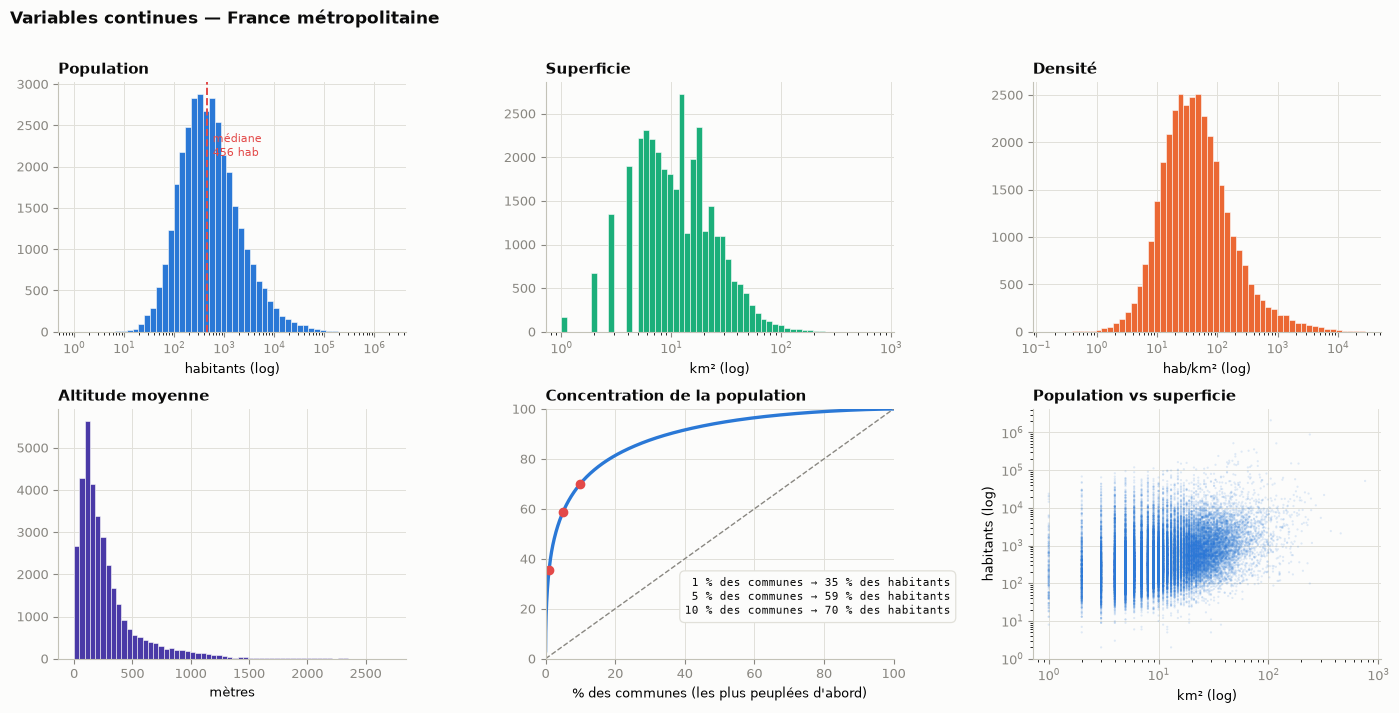

population : médiane 456 · moyenne 1,905 hab
superficie : médiane 11.0 · moyenne 15.8 km²
altitude   : médiane 189 · max 2713 m

→ toutes ces variables sont fortement asymétriques : en features, passer au log est le réflexe.


In [3]:
"""FIG 1 — les variables continues : toutes très asymétriques."""
MET = VIL[~VIL.dom].copy()

fig, ax = plt.subplots(2, 3, figsize=(14, 7))

pop = MET.population[MET.population > 0]
ax[0, 0].hist(pop, bins=np.logspace(0, np.log10(pop.max()), 55), color=BLEU,
              edgecolor="#fcfcfb", linewidth=.4)
ax[0, 0].set_xscale("log")
ax[0, 0].axvline(pop.median(), color=ROUGE, ls="--", lw=1.4)
ax[0, 0].text(pop.median() * 1.3, ax[0, 0].get_ylim()[1] * .80,
              f"médiane\n{pop.median():,.0f} hab", fontsize=8, color=ROUGE, va="top")
ax[0, 0].set_title("Population", fontsize=10.5, weight="bold", loc="left")
ax[0, 0].set_xlabel("habitants (log)")

sup = MET.superficie_km2.dropna()
sup = sup[sup > 0]
ax[0, 1].hist(sup, bins=np.logspace(np.log10(sup.min()), np.log10(sup.max()), 55),
              color=VERT, edgecolor="#fcfcfb", linewidth=.4)
ax[0, 1].set_xscale("log")
ax[0, 1].set_title("Superficie", fontsize=10.5, weight="bold", loc="left")
ax[0, 1].set_xlabel("km² (log)")

den = MET.densite.dropna()
den = den[den > 0]
ax[0, 2].hist(den, bins=np.logspace(np.log10(den.min()), np.log10(den.max()), 55),
              color=ORANGE, edgecolor="#fcfcfb", linewidth=.4)
ax[0, 2].set_xscale("log")
ax[0, 2].set_title("Densité", fontsize=10.5, weight="bold", loc="left")
ax[0, 2].set_xlabel("hab/km² (log)")

ax[1, 0].hist(MET.altitude_moyenne.dropna(), bins=60, color="#4a3aa7",
              edgecolor="#fcfcfb", linewidth=.4)
ax[1, 0].set_title("Altitude moyenne", fontsize=10.5, weight="bold", loc="left")
ax[1, 0].set_xlabel("mètres")

# concentration de la population
s = np.sort(MET.population.dropna().values)[::-1]
ax[1, 1].plot(np.arange(1, len(s) + 1) / len(s) * 100, np.cumsum(s) / s.sum() * 100,
              color=BLEU, lw=2.4)
ax[1, 1].plot([0, 100], [0, 100], color=MUTED, ls="--", lw=1)
lignes_p = []
for p in (1, 5, 10):
    y = np.cumsum(s)[int(len(s) * p / 100)] / s.sum() * 100
    ax[1, 1].plot([p], [y], "o", color=ROUGE, ms=6)
    lignes_p.append(f"{p:>2} % des communes → {y:.0f} % des habitants")
ax[1, 1].text(40, 18, "\n".join(lignes_p), fontsize=8, family="monospace",
              bbox=dict(boxstyle="round,pad=0.45", facecolor="#fcfcfb",
                        edgecolor="#e1e0d9", linewidth=.9))
ax[1, 1].set_xlim(0, 100); ax[1, 1].set_ylim(0, 100)
ax[1, 1].set_title("Concentration de la population", fontsize=10.5, weight="bold", loc="left")
ax[1, 1].set_xlabel("% des communes (les plus peuplées d'abord)")

ax[1, 2].scatter(MET.superficie_km2, MET.population, s=2.5, alpha=.14,
                 color=BLEU, edgecolors="none")
ax[1, 2].set_xscale("log"); ax[1, 2].set_yscale("log")
ax[1, 2].set_title("Population vs superficie", fontsize=10.5, weight="bold", loc="left")
ax[1, 2].set_xlabel("km² (log)"); ax[1, 2].set_ylabel("habitants (log)")

for a in ax.ravel():
    a.grid(color=GRID, lw=.7); a.set_axisbelow(True)
    a.spines[["top", "right"]].set_visible(False); a.tick_params(colors=MUTED)
fig.suptitle("Variables continues — France métropolitaine",
             fontsize=12.5, weight="bold", x=.005, ha="left", y=1.01)
plt.tight_layout(); plt.show()

print(f"population : médiane {MET.population.median():,.0f} · moyenne {MET.population.mean():,.0f} hab")
print(f"superficie : médiane {MET.superficie_km2.median():.1f} · moyenne {MET.superficie_km2.mean():.1f} km²")
print(f"altitude   : médiane {MET.altitude_moyenne.median():.0f} · max {MET.altitude_moyenne.max():.0f} m")
print(f"\n→ toutes ces variables sont fortement asymétriques : en features, "
      f"passer au log est le réflexe.")

## 4. Variables catégorielles et géographie

Le fichier porte plusieurs découpages emboîtés (région, département, EPCI, bassin de vie, aire d'attraction, grille de densité). La **grille de densité INSEE** est la plus intéressante ici : c'est une typologie en 7 niveaux qui résume l'urbanité d'une commune en une seule variable ordinale — bien plus compacte qu'un code postal ou un EPCI.

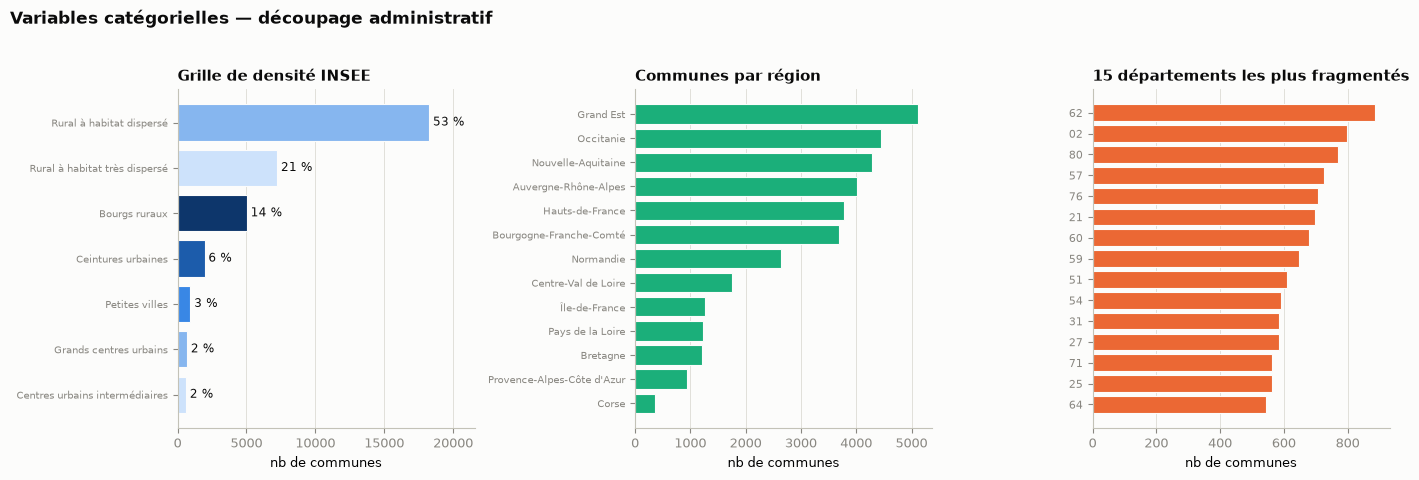

régions : 13 · départements : 96 · EPCI : 1,233 · bassins de vie : 1,681

Grille de densité (typologie INSEE en 7 niveaux) :
   Rural à habitat dispersé               18,262  (52.6 %)
   Rural à habitat très dispersé           7,231  (20.8 %)
   Bourgs ruraux                           5,034  (14.5 %)
   Ceintures urbaines                      1,964  ( 5.7 %)
   Petites villes                            932  ( 2.7 %)
   Grands centres urbains                    692  ( 2.0 %)
   Centres urbains intermédiaires            617  ( 1.8 %)


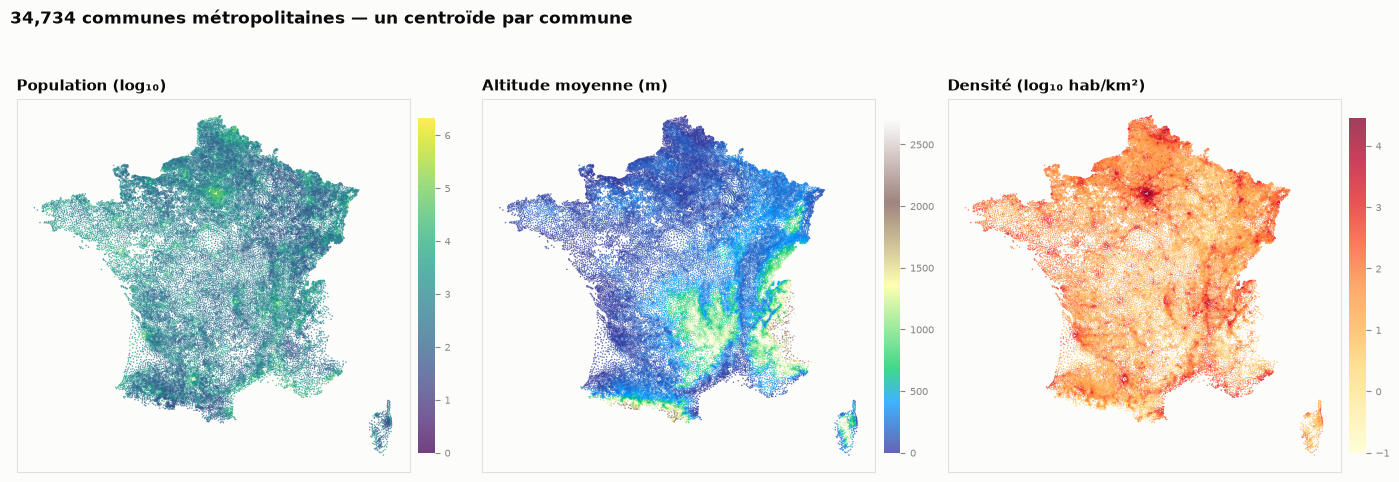

In [4]:
"""FIG 2 — les variables catégorielles  ·  FIG 3 — la carte."""
fig, ax = plt.subplots(1, 3, figsize=(14, 4.6))

gd = MET.grille_densite_texte.value_counts()
ax[0].barh(gd.index[::-1], gd.values[::-1],
           color=["#0d366b", "#1c5cab", "#3987e5", "#86b6ef", "#cde2fb"][:len(gd)][::-1],
           edgecolor="#fcfcfb", linewidth=.8)
for i, v in enumerate(gd.values[::-1]):
    ax[0].text(v + gd.max() * .015, i, f"{100*v/gd.sum():.0f} %", va="center", fontsize=8.5)
ax[0].set_title("Grille de densité INSEE", fontsize=10.5, weight="bold", loc="left")
ax[0].set_xlabel("nb de communes"); ax[0].tick_params(axis="y", labelsize=7.5)
ax[0].set_xlim(0, gd.max() * 1.18)

reg = MET.reg_nom.value_counts().sort_values()
ax[1].barh(reg.index, reg.values, color=VERT, edgecolor="#fcfcfb", linewidth=.8)
ax[1].set_title("Communes par région", fontsize=10.5, weight="bold", loc="left")
ax[1].set_xlabel("nb de communes"); ax[1].tick_params(axis="y", labelsize=7.5)

dep = MET.dep_code.value_counts().nlargest(15).sort_values()
ax[2].barh(dep.index, dep.values, color=ORANGE, edgecolor="#fcfcfb", linewidth=.8)
ax[2].set_title("15 départements les plus fragmentés", fontsize=10.5, weight="bold", loc="left")
ax[2].set_xlabel("nb de communes"); ax[2].tick_params(axis="y", labelsize=8)

for a in ax:
    a.grid(axis="x", color=GRID, lw=.7); a.set_axisbelow(True)
    a.spines[["top", "right"]].set_visible(False); a.tick_params(colors=MUTED)
fig.suptitle("Variables catégorielles — découpage administratif",
             fontsize=12.5, weight="bold", x=.005, ha="left", y=1.03)
plt.tight_layout(); plt.show()

print(f"régions : {MET.reg_nom.nunique()} · départements : {MET.dep_code.nunique()} "
      f"· EPCI : {MET.epci_code.nunique():,} · bassins de vie : {MET.code_bassin_de_vie.nunique():,}")
print("\nGrille de densité (typologie INSEE en 7 niveaux) :")
for k, v in gd.items():
    print(f"   {k:38s} {v:6,}  ({100*v/gd.sum():4.1f} %)")

# ── FIG 3 : la carte ──
fig, ax = plt.subplots(1, 3, figsize=(14, 5))
G = MET.dropna(subset=["latitude_centre", "longitude_centre"])
ASP = 1 / np.cos(np.radians(46))

for a, col, cm, titre, norm in [
    (ax[0], np.log10(G.population.clip(lower=1)), "viridis", "Population (log₁₀)", None),
    (ax[1], G.altitude_moyenne, "terrain", "Altitude moyenne (m)", None),
    (ax[2], np.log10(G.densite.clip(lower=.1)), "YlOrRd", "Densité (log₁₀ hab/km²)", None),
]:
    sc = a.scatter(G.longitude_centre, G.latitude_centre, c=col, s=1.2, cmap=cm,
                   alpha=.75, edgecolors="none")
    a.set_aspect(ASP)
    a.set_title(titre, fontsize=10.5, weight="bold", loc="left")
    a.set_xticks([]); a.set_yticks([])
    for s in a.spines.values():
        s.set_color("#e1e0d9")
    cb = fig.colorbar(sc, ax=a, fraction=.04, pad=.02)
    cb.outline.set_visible(False); cb.ax.tick_params(labelsize=7.5, colors=MUTED)
fig.suptitle(f"{len(G):,} communes métropolitaines — un centroïde par commune",
             fontsize=12.5, weight="bold", x=.005, ha="left", y=1.02)
plt.tight_layout(); plt.show()

## 5. Synthèse

### Ce qui est établi

| Point | Résultat |
|---|---|
| Volume | 34 868 communes × 62 colonnes |
| **Clé `code_insee`** | **0 doublon**, toutes à 5 caractères, `typecom` uniforme (`COM`) |
| Complétude | 38 colonnes sur 62 sans aucun manquant |
| Coordonnées | 5 communes sans lat/lon (0,01 %) |
| Métropole / DOM | 34 739 / 129 — les DOM sont hors de la bbox météo européenne |
| Centre vs mairie | écart médian 0,77 km — **indifférent** face à une maille météo de 28 km |
| Cohérence densité | population / superficie retrouve la densité annoncée à ~2 % près |

### Colonnes retenues comme features candidates

| Colonne | Rôle attendu |
|---|---|
| `latitude_centre`, `longitude_centre` | rattachement à la maille météo — **la raison d'être de ce fichier** |
| `population`, `densite` | proxy de la présence humaine (9 feux sur 10 sont d'origine humaine) |
| `superficie_km2` | exposition : une grande commune a plus de chances de contenir un départ |
| `altitude_moyenne/min/max` | l'amplitude min-max approxime le relief |
| `grille_densite` | typologie urbain/rural en une variable ordinale |
| `dep_code`, `reg_code` | découpage pour la validation géographique |

### Points d'attention

1. **Passer au log** pour population, densité et superficie avant modélisation.
2. **Les 129 DOM sont à écarter** du périmètre — hors couverture météo et hors CORINE.
3. `superficie_km2` est manquante pour 0,37 % des communes : à traiter avant d'en faire un dénominateur.
4. 4 % des communes ont une incohérence altitude min/moyenne/max — marginal, mais à ne pas utiliser aveuglément.